## Data Analytics

### Chapter 16: Covariance and Correlation

Covariance and correlation are two important statistical measures used in Exploratory Data Analysis (EDA) to examine the relationship between numerical variables. They help determine whether variables tend to increase or decrease together and how strong those relationships are. 

#### Generate Synthetic Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
n = 100

age = np.random.randint(18, 31, n)
height = 145 + age * 1.5 + np.random.normal(0, 4, n)
weight = 20 + height * 0.38 + np.random.normal(0, 5, n)

df = pd.DataFrame({
    "Age": age,
    "Height": np.round(height, 1),
    "Weight": np.round(weight, 1)
})

df

,Age,Height,Weight
0,24,181.4,94.8
1,21,178.2,92.1
2,30,186.2,91.8
3,28,182.8,82.2
4,25,175.0,81.4
...,...,...,...
95,30,188.9,88.1
96,19,172.9,85.2
97,22,180.5,86.1
98,25,187.5,99.2


#### 16.1. Covariance - Covariance Matrix

Covariance measures how two variables vary together. It indicates whether changes in one variable are associated with changes in another.

- **Positive covariance (> 0):** Both variables tend to increase or decrease together.
- **Negative covariance (< 0):** One variable tends to increase while the other decreases.
- **Covariance close to 0:** Little or no linear relationship exists between the variables.

A Covariance Matrix is a square matrix that displays the covariance between every pair of numerical features in a dataset.

In [3]:
# Covariance Matrix
cov_matrix = df.cov()

cov_matrix

,Age,Height,Weight
Age,13.188990,18.867778,7.613323
Height,18.867778,43.207778,18.139485
Weight,7.613323,18.139485,33.901304


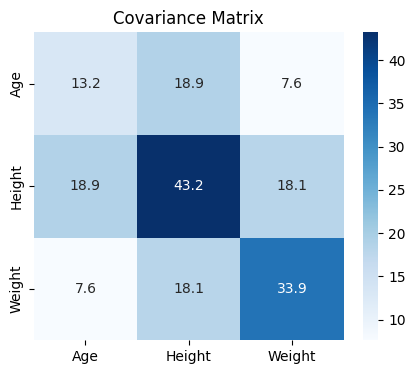

In [4]:
plt.figure(figsize=(5,4))
sns.heatmap(cov_matrix,
            annot=True,
            cmap="Blues",
            fmt=".1f")

plt.title("Covariance Matrix")
plt.show()

#### 16.2. Correlation - Correlation Matrix

Correlation measures both the strength and direction of the linear relationship between two variables. Unlike covariance, it is standardized, allowing relationships between different pairs of variables to be compared directly.

The **Pearson correlation coefficient** (*r*) is defined within the range $1 \le r \le 1$ where:

- **$r > 0$:** Positive linear relationship (both variables increase together).
- **$r < 0$:** Negative linear relationship (one increases while the other decreases).
- **$r = 0$:** No linear relationship.

The closer the coefficient is to **±1**, the stronger the linear relationship. Values near **0** indicate weak or no linear relationship.

A **Correlation Matrix** is the standardized version of the covariance matrix. Every value represents the correlation coefficient between two features.

For a dataset with **n features**, the correlation matrix has dimensions **n × n**.

- Each row and column represents one feature.
- Every cell shows the correlation between two features.
- The diagonal values are always **1**, since every variable is perfectly correlated with itself.

In [5]:
corr_matrix = df.corr()

corr_matrix

,Age,Height,Weight
Age,1.000000,0.790377,0.360048
Height,0.790377,1.000000,0.473954
Weight,0.360048,0.473954,1.000000


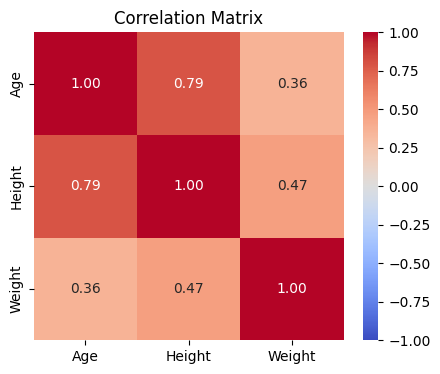

In [6]:
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

Extra: A synthetic dataset with 9 numerical features

In [7]:
n = 100

# Base feature
feature1 = np.random.normal(50, 10, n)

# Strong positive correlation with Feature1
feature2 = feature1 * 1.2 + np.random.normal(0, 5, n)

# Moderate positive correlation
feature3 = feature1 * 0.7 + np.random.normal(0, 8, n)

# Strong negative correlation
feature4 = 120 - feature1 + np.random.normal(0, 5, n)

# Weak correlation
feature5 = feature1 * 0.2 + np.random.normal(30, 10, n)

# Independent random feature
feature6 = np.random.normal(60, 15, n)

# Correlated with Feature6
feature7 = feature6 * 0.9 + np.random.normal(0, 6, n)

# Combination of Feature2 and Feature6
feature8 = 0.5 * feature2 + 0.5 * feature6 + np.random.normal(0, 5, n)

# Mostly random
feature9 = np.random.normal(40, 12, n)

df_temp = pd.DataFrame({
    "Feature1": np.round(feature1, 2),
    "Feature2": np.round(feature2, 2),
    "Feature3": np.round(feature3, 2),
    "Feature4": np.round(feature4, 2),
    "Feature5": np.round(feature5, 2),
    "Feature6": np.round(feature6, 2),
    "Feature7": np.round(feature7, 2),
    "Feature8": np.round(feature8, 2),
    "Feature9": np.round(feature9, 2)
})

df_temp

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9
0,42.67,49.62,31.88,76.26,49.05,80.20,73.90,70.59,45.79
1,44.22,55.35,27.32,76.48,36.37,61.90,43.20,56.34,34.96
2,48.64,59.30,17.82,75.18,39.07,48.61,32.58,53.39,53.58
3,42.06,54.61,45.14,77.99,46.49,59.95,52.16,51.15,36.70
4,46.32,62.21,30.31,78.09,47.67,58.97,55.80,61.03,56.61
...,...,...,...,...,...,...,...,...,...
95,36.43,47.73,29.46,80.12,35.06,51.67,46.26,65.17,43.35
96,34.18,41.29,29.05,88.90,39.81,35.92,44.45,37.73,47.42
97,50.79,62.15,29.03,66.06,46.39,68.52,57.23,61.54,41.69
98,60.61,76.85,57.20,54.82,51.62,47.91,32.89,60.32,46.07


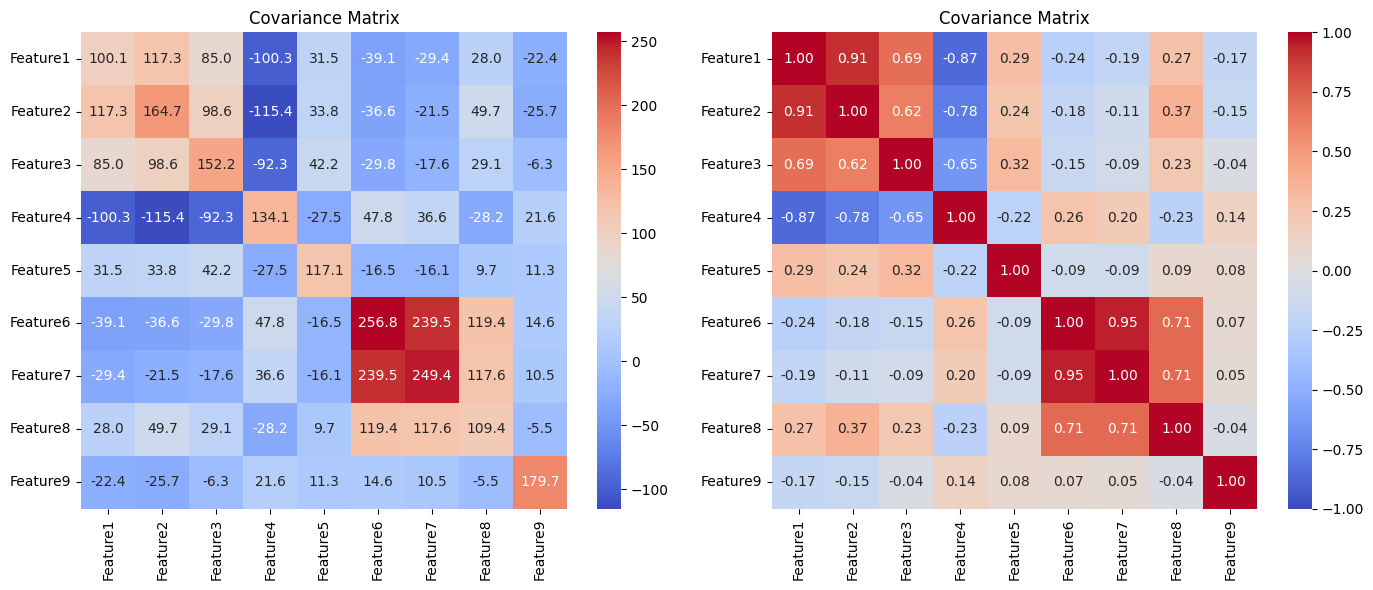

In [14]:
cov_matrix = df_temp.cov()
corr_matrix = df_temp.corr()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Covariance Matrix
sns.heatmap(cov_matrix, ax=axes[0],
            annot=True,
            cmap="coolwarm",
            fmt=".1f")

axes[0].set_title("Covariance Matrix")

# Correlation Matrix
sns.heatmap(corr_matrix, ax=axes[1],
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            fmt=".2f")
axes[1].set_title("Covariance Matrix")

plt.tight_layout()
plt.show()